# Дифференцирование

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html#matplotlib.pyplot.axhline
* https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p
* https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html
* https://en.wikipedia.org/wiki/Finite_difference
* https://pythonnumericalmethods.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html
* https://en.wikipedia.org/wiki/Gradient_descent
* https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
* https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29

## Задачи для совместного разбора

1\. Дана функция $f(x) = x^2$. Найдите производную этой функции различными способами

Символьная производная f'(x) = 2*x


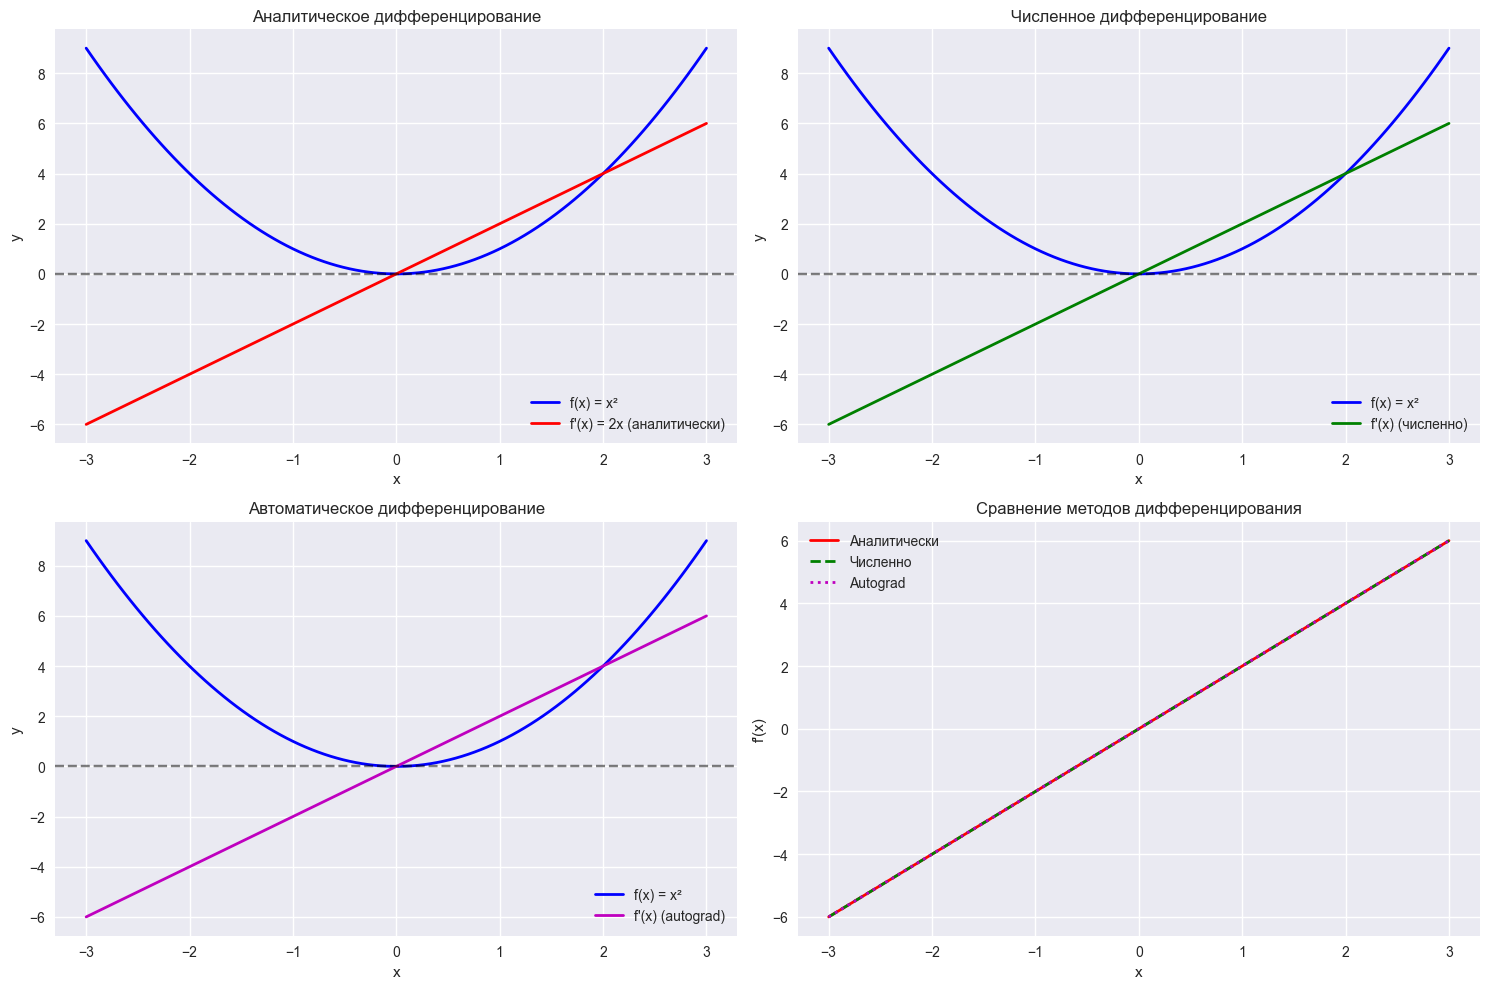

Все методы дают одинаковый результат для простой функции f(x) = x²


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import torch
from scipy.optimize import minimize_scalar

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

# Задача 1: f(x) = x^2 - различные способы нахождения производной

# Способ 1: Аналитически
def f_x2(x):
    return x**2

def f_prime_x2_analytical(x):
    return 2*x

# Способ 2: Символьное дифференцирование
x = sp.Symbol('x')
f_symbolic = x**2
f_prime_symbolic = sp.diff(f_symbolic, x)
print(f"Символьная производная f'(x) = {f_prime_symbolic}")

# Способ 3: Численное дифференцирование
def f_prime_x2_numerical(x, h=1e-7):
    return (f_x2(x + h) - f_x2(x - h)) / (2 * h)

# Способ 4: Автоматическое дифференцирование (PyTorch)
def f_prime_x2_autograd(x_val):
    x_tensor = torch.tensor(x_val, requires_grad=True)
    y = x_tensor**2
    y.backward()
    return x_tensor.grad.item()

# Построение графиков
x_vals = np.linspace(-3, 3, 100)
y_vals = f_x2(x_vals)
y_prime_analytical = f_prime_x2_analytical(x_vals)
y_prime_numerical = [f_prime_x2_numerical(x) for x in x_vals]
y_prime_autograd = [f_prime_x2_autograd(x) for x in x_vals]

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(x_vals, y_vals, 'b-', label='f(x) = x²', linewidth=2)
plt.plot(x_vals, y_prime_analytical, 'r-', label="f'(x) = 2x (аналитически)", linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.legend()
plt.title('Аналитическое дифференцирование')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2, 2, 2)
plt.plot(x_vals, y_vals, 'b-', label='f(x) = x²', linewidth=2)
plt.plot(x_vals, y_prime_numerical, 'g-', label="f'(x) (численно)", linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.legend()
plt.title('Численное дифференцирование')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2, 2, 3)
plt.plot(x_vals, y_vals, 'b-', label='f(x) = x²', linewidth=2)
plt.plot(x_vals, y_prime_autograd, 'm-', label="f'(x) (autograd)", linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.grid(True)
plt.legend()
plt.title('Автоматическое дифференцирование')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2, 2, 4)
plt.plot(x_vals, y_prime_analytical, 'r-', label='Аналитически', linewidth=2)
plt.plot(x_vals, y_prime_numerical, 'g--', label='Численно', linewidth=2)
plt.plot(x_vals, y_prime_autograd, 'm:', label='Autograd', linewidth=2)
plt.grid(True)
plt.legend()
plt.title('Сравнение методов дифференцирования')
plt.xlabel('x')
plt.ylabel("f'(x)")

plt.tight_layout()
plt.show()

print("Все методы дают одинаковый результат для простой функции f(x) = x²")

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дана функция $f(x)$. Найдите (аналитически) производную данной функции $f'(x)$ и реализуйте две этих функции. Постройте в одной системе координат графики $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

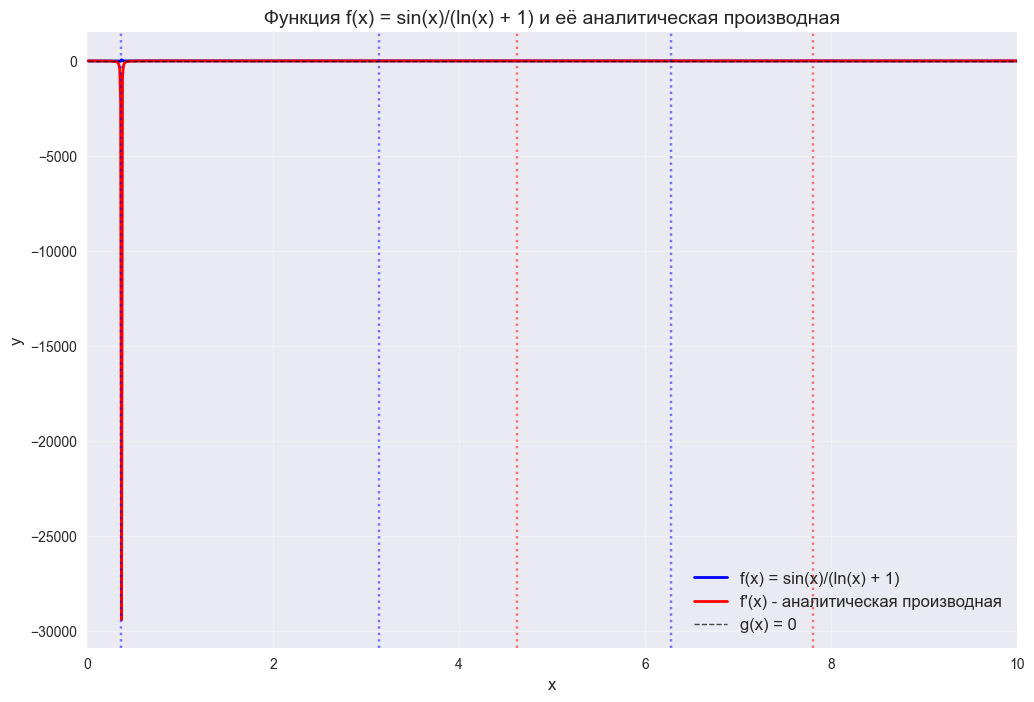

Найдено 4 пересечений f(x) с осью x
Найдено 2 пересечений f'(x) с осью x
Аналитическая производная: f'(x) = [cos(x)*(ln(x)+1) - sin(x)/x] / (ln(x)+1)²


In [2]:
# Задача 1: Аналитическое дифференцирование f(x) = sin(x)/(ln(x) + 1)

# Аналитическое вычисление производной с использованием правила частного
# f(x) = sin(x)/(ln(x) + 1)
# f'(x) = [cos(x) * (ln(x) + 1) - sin(x) * (1/x)] / (ln(x) + 1)²

def f(x):
    """Исходная функция f(x) = sin(x)/(ln(x) + 1)"""
    return np.sin(x) / (np.log(x) + 1)

def f_prime_analytical(x):
    """Аналитическая производная f'(x)"""
    numerator = np.cos(x) * (np.log(x) + 1) - np.sin(x) * (1/x)
    denominator = (np.log(x) + 1)**2
    return numerator / denominator

def g(x):
    """Функция g(x) = 0 для построения оси x"""
    return np.zeros_like(x)

# Построение графиков на полуинтервале (0, 10]
x_vals = np.linspace(0.01, 10, 1000)  # Избегаем x=0 из-за ln(x)

# Вычисление значений функций
y_vals = f(x_vals)
y_prime_vals = f_prime_analytical(x_vals)
zero_vals = g(x_vals)

# Построение графиков
plt.figure(figsize=(12, 8))
plt.plot(x_vals, y_vals, 'b-', label='f(x) = sin(x)/(ln(x) + 1)', linewidth=2)
plt.plot(x_vals, y_prime_vals, 'r-', label="f'(x) - аналитическая производная", linewidth=2)
plt.plot(x_vals, zero_vals, 'k--', label='g(x) = 0', linewidth=1, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.title('Функция f(x) = sin(x)/(ln(x) + 1) и её аналитическая производная', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.xlim(0, 10)

# Добавим вертикальные линии в точках пересечения с осью x
zero_crossings_f = []
zero_crossings_fprime = []

for i in range(len(y_vals)-1):
    if y_vals[i] * y_vals[i+1] < 0:
        zero_crossings_f.append(x_vals[i])
    if y_prime_vals[i] * y_prime_vals[i+1] < 0:
        zero_crossings_fprime.append(x_vals[i])

for zc in zero_crossings_f[:3]:  # Показываем только первые 3
    plt.axvline(x=zc, color='blue', linestyle=':', alpha=0.5)
    
for zc in zero_crossings_fprime[:3]:
    plt.axvline(x=zc, color='red', linestyle=':', alpha=0.5)

plt.show()

print(f"Найдено {len(zero_crossings_f)} пересечений f(x) с осью x")
print(f"Найдено {len(zero_crossings_fprime)} пересечений f'(x) с осью x")
print(f"Аналитическая производная: f'(x) = [cos(x)*(ln(x)+1) - sin(x)/x] / (ln(x)+1)²")

<p class="task" id="2"></p>

2\. Дана функция $f(x)$. Найдите (используя символьные вычисления) производную данной функции $f'(x)$. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

Символьная функция:
f(x) = sin(x)/(log(x) + 1)

Символьная производная:
f'(x) = cos(x)/(log(x) + 1) - sin(x)/(x*(log(x) + 1)**2)

Упрощенная символьная производная:
f'(x) = (x*(log(x) + 1)*cos(x) - sin(x))/(x*(log(x) + 1)**2)


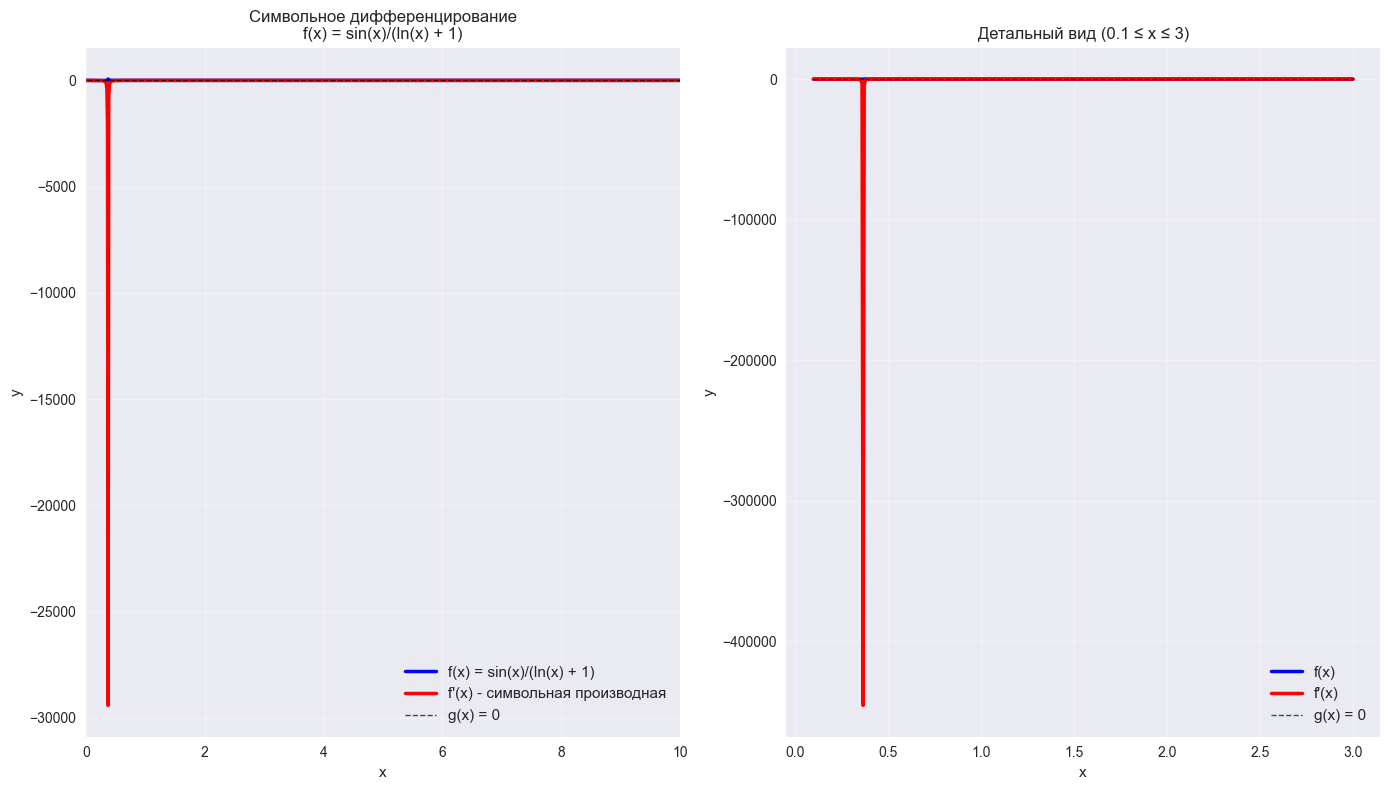


Производная в LaTeX формате:
\frac{x \left(\log{\left(x \right)} + 1\right) \cos{\left(x \right)} - \sin{\left(x \right)}}{x \left(\log{\left(x \right)} + 1\right)^{2}}

Значения функции и производной в контрольных точках:
x = 0.5: f(x) = 1.562396, f'(x) = -7.323410
x = 1: f(x) = 0.841471, f'(x) = -0.301169
x = 2: f(x) = 0.537046, f'(x) = -0.404377
x = 5: f(x) = -0.367483, f'(x) = 0.136872


In [3]:
# Задача 2: Символьное дифференцирование f(x) = sin(x)/(ln(x) + 1)

# Определяем символьную переменную
x_sym = sp.Symbol('x', positive=True)  # positive=True для корректности ln(x)

# Определяем функцию символьно
f_symbolic = sp.sin(x_sym) / (sp.log(x_sym) + 1)

# Находим производную символьно
f_prime_symbolic = sp.diff(f_symbolic, x_sym)

print("Символьная функция:")
print(f"f(x) = {f_symbolic}")
print("\nСимвольная производная:")
print(f"f'(x) = {f_prime_symbolic}")
print("\nУпрощенная символьная производная:")
f_prime_simplified = sp.simplify(f_prime_symbolic)
print(f"f'(x) = {f_prime_simplified}")

# Преобразуем символьные функции в численные для построения графиков
f_numeric = sp.lambdify(x_sym, f_symbolic, 'numpy')
f_prime_numeric = sp.lambdify(x_sym, f_prime_symbolic, 'numpy')

# Построение графиков на полуинтервале (0, 10]
x_vals = np.linspace(0.01, 10, 1000)

# Вычисление значений функций
y_vals = f_numeric(x_vals)
y_prime_vals = f_prime_numeric(x_vals)
zero_vals = np.zeros_like(x_vals)

# Построение графиков
plt.figure(figsize=(14, 8))

# Основной график
plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals, 'b-', label='f(x) = sin(x)/(ln(x) + 1)', linewidth=2.5)
plt.plot(x_vals, y_prime_vals, 'r-', label="f'(x) - символьная производная", linewidth=2.5)
plt.plot(x_vals, zero_vals, 'k--', label='g(x) = 0', linewidth=1, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.title('Символьное дифференцирование\nf(x) = sin(x)/(ln(x) + 1)', fontsize=12)
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.xlim(0, 10)

# Детализированный вид для первых 3 единиц
plt.subplot(1, 2, 2)
x_detail = np.linspace(0.1, 3, 500)
y_detail = f_numeric(x_detail)
y_prime_detail = f_prime_numeric(x_detail)
zero_detail = np.zeros_like(x_detail)

plt.plot(x_detail, y_detail, 'b-', label='f(x)', linewidth=2.5)
plt.plot(x_detail, y_prime_detail, 'r-', label="f'(x)", linewidth=2.5)
plt.plot(x_detail, zero_detail, 'k--', label='g(x) = 0', linewidth=1, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.title('Детальный вид (0.1 ≤ x ≤ 3)', fontsize=12)
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)

plt.tight_layout()
plt.show()

# Выводим LaTeX представление производной
print("\nПроизводная в LaTeX формате:")
print(sp.latex(f_prime_simplified))

# Проверим значения в нескольких точках
test_points = [0.5, 1, 2, 5]
print("\nЗначения функции и производной в контрольных точках:")
for point in test_points:
    f_val = float(f_numeric(point))
    f_prime_val = float(f_prime_numeric(point))
    print(f"x = {point}: f(x) = {f_val:.6f}, f'(x) = {f_prime_val:.6f}")

<p class="task" id="3"></p>

3\. Дана функция $f(x)$. Найдите (численно) производную данной функции $f'(x)$ на полуинтервале (0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

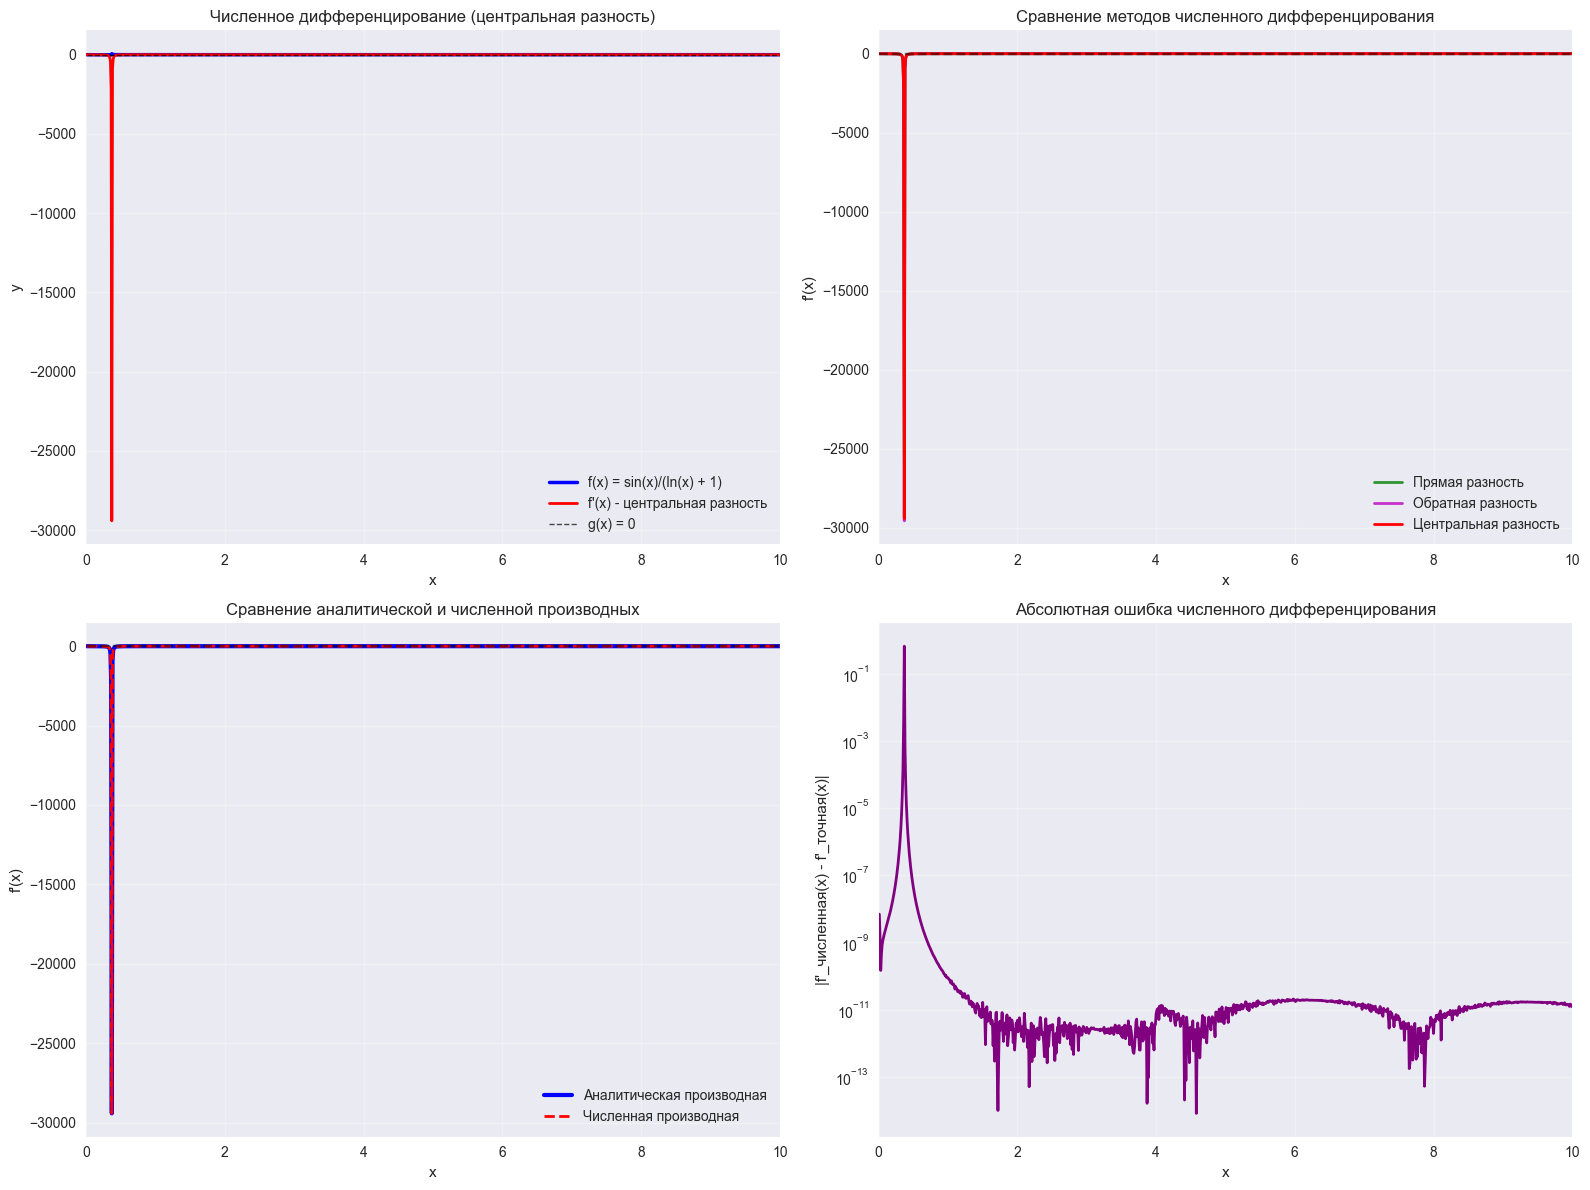

Максимальная абсолютная ошибка: 6.54e-01
Средняя абсолютная ошибка: 6.59e-04
h = 1e-03: ошибка = 3.02e-08
h = 1e-04: ошибка = 3.02e-10
h = 1e-05: ошибка = 4.80e-12
h = 1e-06: ошибка = 1.04e-11
h = 1e-07: ошибка = 1.77e-10
h = 1e-08: ошибка = 5.73e-09


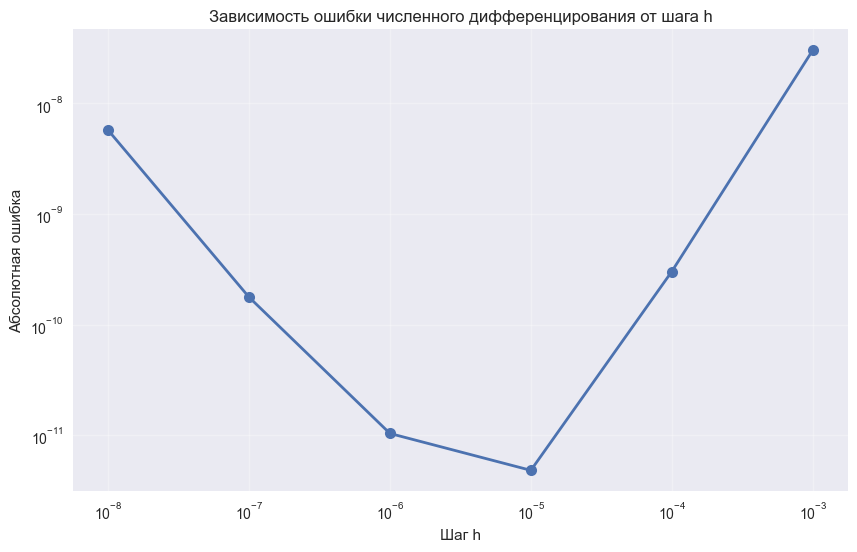

In [4]:
# Задача 3: Численное дифференцирование f(x) = sin(x)/(ln(x) + 1)

def f_for_numerical(x):
    """Функция для численного дифференцирования"""
    return np.sin(x) / (np.log(x) + 1)

def numerical_derivative(func, x, h=1e-5, method='central'):
    """Численное дифференцирование различными методами"""
    if method == 'forward':
        return (func(x + h) - func(x)) / h
    elif method == 'backward':
        return (func(x) - func(x - h)) / h
    elif method == 'central':
        return (func(x + h) - func(x - h)) / (2 * h)
    else:
        raise ValueError("Метод должен быть 'forward', 'backward' или 'central'")

# Построение графиков на полуинтервале (0, 10]
x_vals = np.linspace(0.01, 10, 1000)

# Вычисление значений функции
y_vals = f_for_numerical(x_vals)

# Численное дифференцирование разными методами
y_prime_forward = [numerical_derivative(f_for_numerical, x, method='forward') for x in x_vals[:-1]]
y_prime_backward = [numerical_derivative(f_for_numerical, x, method='backward') for x in x_vals[1:]]
y_prime_central = [numerical_derivative(f_for_numerical, x, method='central') for x in x_vals]

# Для сравнения - аналитическая производная
y_prime_exact = f_prime_analytical(x_vals)

zero_vals = np.zeros_like(x_vals)

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Функция и центральная разность
axes[0, 0].plot(x_vals, y_vals, 'b-', label='f(x) = sin(x)/(ln(x) + 1)', linewidth=2.5)
axes[0, 0].plot(x_vals, y_prime_central, 'r-', label="f'(x) - центральная разность", linewidth=2)
axes[0, 0].plot(x_vals, zero_vals, 'k--', label='g(x) = 0', linewidth=1, alpha=0.7)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_title('Численное дифференцирование (центральная разность)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_xlim(0, 10)

# График 2: Сравнение методов численного дифференцирования
axes[0, 1].plot(x_vals[:-1], y_prime_forward, 'g-', label='Прямая разность', linewidth=2, alpha=0.8)
axes[0, 1].plot(x_vals[1:], y_prime_backward, 'm-', label='Обратная разность', linewidth=2, alpha=0.8)
axes[0, 1].plot(x_vals, y_prime_central, 'r-', label='Центральная разность', linewidth=2)
axes[0, 1].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_title('Сравнение методов численного дифференцирования')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel("f'(x)")
axes[0, 1].set_xlim(0, 10)

# График 3: Сравнение с аналитической производной
axes[1, 0].plot(x_vals, y_prime_exact, 'b-', label='Аналитическая производная', linewidth=3)
axes[1, 0].plot(x_vals, y_prime_central, 'r--', label='Численная производная', linewidth=2)
axes[1, 0].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_title('Сравнение аналитической и численной производных')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel("f'(x)")
axes[1, 0].set_xlim(0, 10)

# График 4: Ошибка численного дифференцирования
error = np.abs(np.array(y_prime_central) - y_prime_exact)
axes[1, 1].semilogy(x_vals, error, 'purple', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_title('Абсолютная ошибка численного дифференцирования')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('|f\'_численная(x) - f\'_точная(x)|')
axes[1, 1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

# Анализ точности
max_error = np.max(error)
mean_error = np.mean(error)
print(f"Максимальная абсолютная ошибка: {max_error:.2e}")
print(f"Средняя абсолютная ошибка: {mean_error:.2e}")

# Исследование влияния шага h на точность
h_values = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
test_point = 2.0
errors_by_h = []

for h in h_values:
    numerical_val = numerical_derivative(f_for_numerical, test_point, h=h, method='central')
    exact_val = f_prime_analytical(test_point)
    error_h = abs(numerical_val - exact_val)
    errors_by_h.append(error_h)
    print(f"h = {h:.0e}: ошибка = {error_h:.2e}")

plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors_by_h, 'o-', linewidth=2, markersize=8)
plt.grid(True, alpha=0.3)
plt.title('Зависимость ошибки численного дифференцирования от шага h')
plt.xlabel('Шаг h')
plt.ylabel('Абсолютная ошибка')
plt.show()

<p class="task" id="4"></p>

4\. Найдите локальный минимум функции $f(x)$ при помощи метода градиетного спуска. В качестве начальной точки используйте $x_0 = 4$. Найдите локальный максимум этой же функции, используя в качестве начальной точки $x_0'=9$.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

Поиск локального минимума с x0 = 4:
Сходимость достигнута за 257 итераций
Найденный локальный минимум: x = 4.627216, f(x) = -0.393520

Поиск локального максимума с x0 = 9:
Сходимость достигнута за 327 итераций
Найденный локальный максимум: x = 7.812145, f(x) = 0.326973


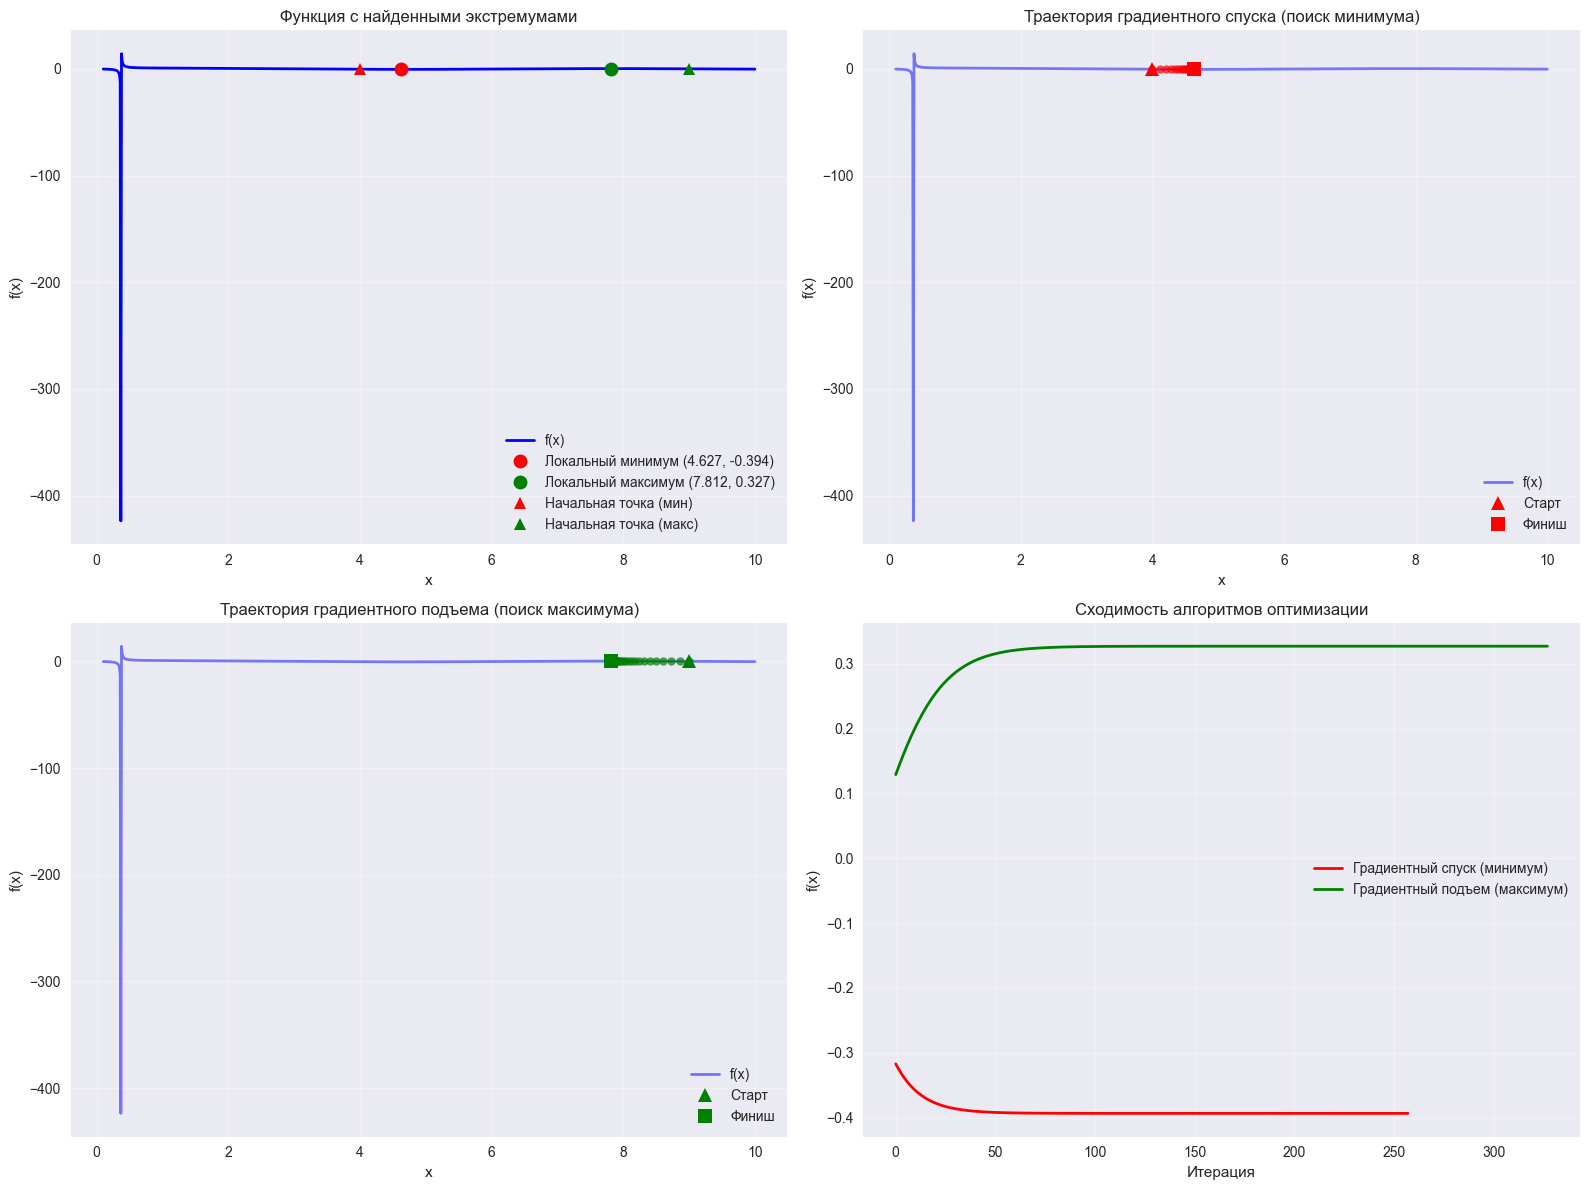


Проверка через производную:
f'(4.627216) = -0.00000989 (должно быть ≈ 0 для экстремума)
f'(7.812145) = -0.00000969 (должно быть ≈ 0 для экстремума)


In [5]:
# Задача 4: Градиентный спуск для поиска локальных экстремумов

def gradient_descent(func, grad_func, x0, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
    """Реализация градиентного спуска"""
    x = x0
    history = [x]
    
    for i in range(max_iterations):
        grad = grad_func(x)
        x_new = x - learning_rate * grad
        
        history.append(x_new)
        
        # Проверка сходимости
        if abs(x_new - x) < tolerance:
            print(f"Сходимость достигнута за {i+1} итераций")
            break
        
        x = x_new
    
    return x, history

def gradient_ascent(func, grad_func, x0, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
    """Реализация градиентного подъема (для поиска максимума)"""
    x = x0
    history = [x]
    
    for i in range(max_iterations):
        grad = grad_func(x)
        x_new = x + learning_rate * grad  # Плюс для подъема
        
        history.append(x_new)
        
        # Проверка сходимости
        if abs(x_new - x) < tolerance:
            print(f"Сходимость достигнута за {i+1} итераций")
            break
        
        x = x_new
    
    return x, history

# Поиск локального минимума с начальной точкой x0 = 4
print("Поиск локального минимума с x0 = 4:")
x_min, history_min = gradient_descent(f, f_prime_analytical, x0=4, learning_rate=0.1)
print(f"Найденный локальный минимум: x = {x_min:.6f}, f(x) = {f(x_min):.6f}")

# Поиск локального максимума с начальной точкой x0 = 9
print("\nПоиск локального максимума с x0 = 9:")
x_max, history_max = gradient_ascent(f, f_prime_analytical, x0=9, learning_rate=0.1)
print(f"Найденный локальный максимум: x = {x_max:.6f}, f(x) = {f(x_max):.6f}")

# Визуализация процесса оптимизации
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График функции с найденными экстремумами
x_plot = np.linspace(0.1, 10, 1000)
y_plot = f(x_plot)
y_prime_plot = f_prime_analytical(x_plot)

axes[0, 0].plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
axes[0, 0].plot(x_min, f(x_min), 'ro', markersize=10, label=f'Локальный минимум ({x_min:.3f}, {f(x_min):.3f})')
axes[0, 0].plot(x_max, f(x_max), 'go', markersize=10, label=f'Локальный максимум ({x_max:.3f}, {f(x_max):.3f})')
axes[0, 0].plot([4], [f(4)], 'r^', markersize=8, label='Начальная точка (мин)')
axes[0, 0].plot([9], [f(9)], 'g^', markersize=8, label='Начальная точка (макс)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_title('Функция с найденными экстремумами')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('f(x)')

# Траектория поиска минимума
axes[0, 1].plot(x_plot, y_plot, 'b-', linewidth=2, alpha=0.5, label='f(x)')
for i, x_val in enumerate(history_min[::5]):  # Каждая 5-я точка
    axes[0, 1].plot(x_val, f(x_val), 'ro', markersize=6, alpha=0.7)
    if i < len(history_min[::5]) - 1:
        x_next = history_min[::5][i+1]
        axes[0, 1].arrow(x_val, f(x_val), x_next-x_val, f(x_next)-f(x_val), 
                        head_width=0.05, head_length=0.02, fc='red', ec='red', alpha=0.6)
axes[0, 1].plot(history_min[0], f(history_min[0]), 'r^', markersize=10, label='Старт')
axes[0, 1].plot(history_min[-1], f(history_min[-1]), 'rs', markersize=10, label='Финиш')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_title('Траектория градиентного спуска (поиск минимума)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('f(x)')

# Траектория поиска максимума
axes[1, 0].plot(x_plot, y_plot, 'b-', linewidth=2, alpha=0.5, label='f(x)')
for i, x_val in enumerate(history_max[::5]):  # Каждая 5-я точка
    axes[1, 0].plot(x_val, f(x_val), 'go', markersize=6, alpha=0.7)
    if i < len(history_max[::5]) - 1:
        x_next = history_max[::5][i+1]
        axes[1, 0].arrow(x_val, f(x_val), x_next-x_val, f(x_next)-f(x_val), 
                        head_width=0.05, head_length=0.02, fc='green', ec='green', alpha=0.6)
axes[1, 0].plot(history_max[0], f(history_max[0]), 'g^', markersize=10, label='Старт')
axes[1, 0].plot(history_max[-1], f(history_max[-1]), 'gs', markersize=10, label='Финиш')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_title('Траектория градиентного подъема (поиск максимума)')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('f(x)')

# Сходимость алгоритмов
axes[1, 1].plot(range(len(history_min)), [f(x) for x in history_min], 'r-', 
               linewidth=2, label='Градиентный спуск (минимум)')
axes[1, 1].plot(range(len(history_max)), [f(x) for x in history_max], 'g-', 
               linewidth=2, label='Градиентный подъем (максимум)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_title('Сходимость алгоритмов оптимизации')
axes[1, 1].set_xlabel('Итерация')
axes[1, 1].set_ylabel('f(x)')

plt.tight_layout()
plt.show()

# Проверка найденных экстремумов через производную
print(f"\nПроверка через производную:")
print(f"f'({x_min:.6f}) = {f_prime_analytical(x_min):.8f} (должно быть ≈ 0 для экстремума)")
print(f"f'({x_max:.6f}) = {f_prime_analytical(x_max):.8f} (должно быть ≈ 0 для экстремума)")

<p class="task" id="5"></p>

5\. Дана функция $f(x)$. Найдите (используя возможности по автоматическому дифференцированию пакета `torch`) производную данной функции $f'(x)$ на отрезке [0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку. 

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

Вычисление производной через PyTorch autograd...


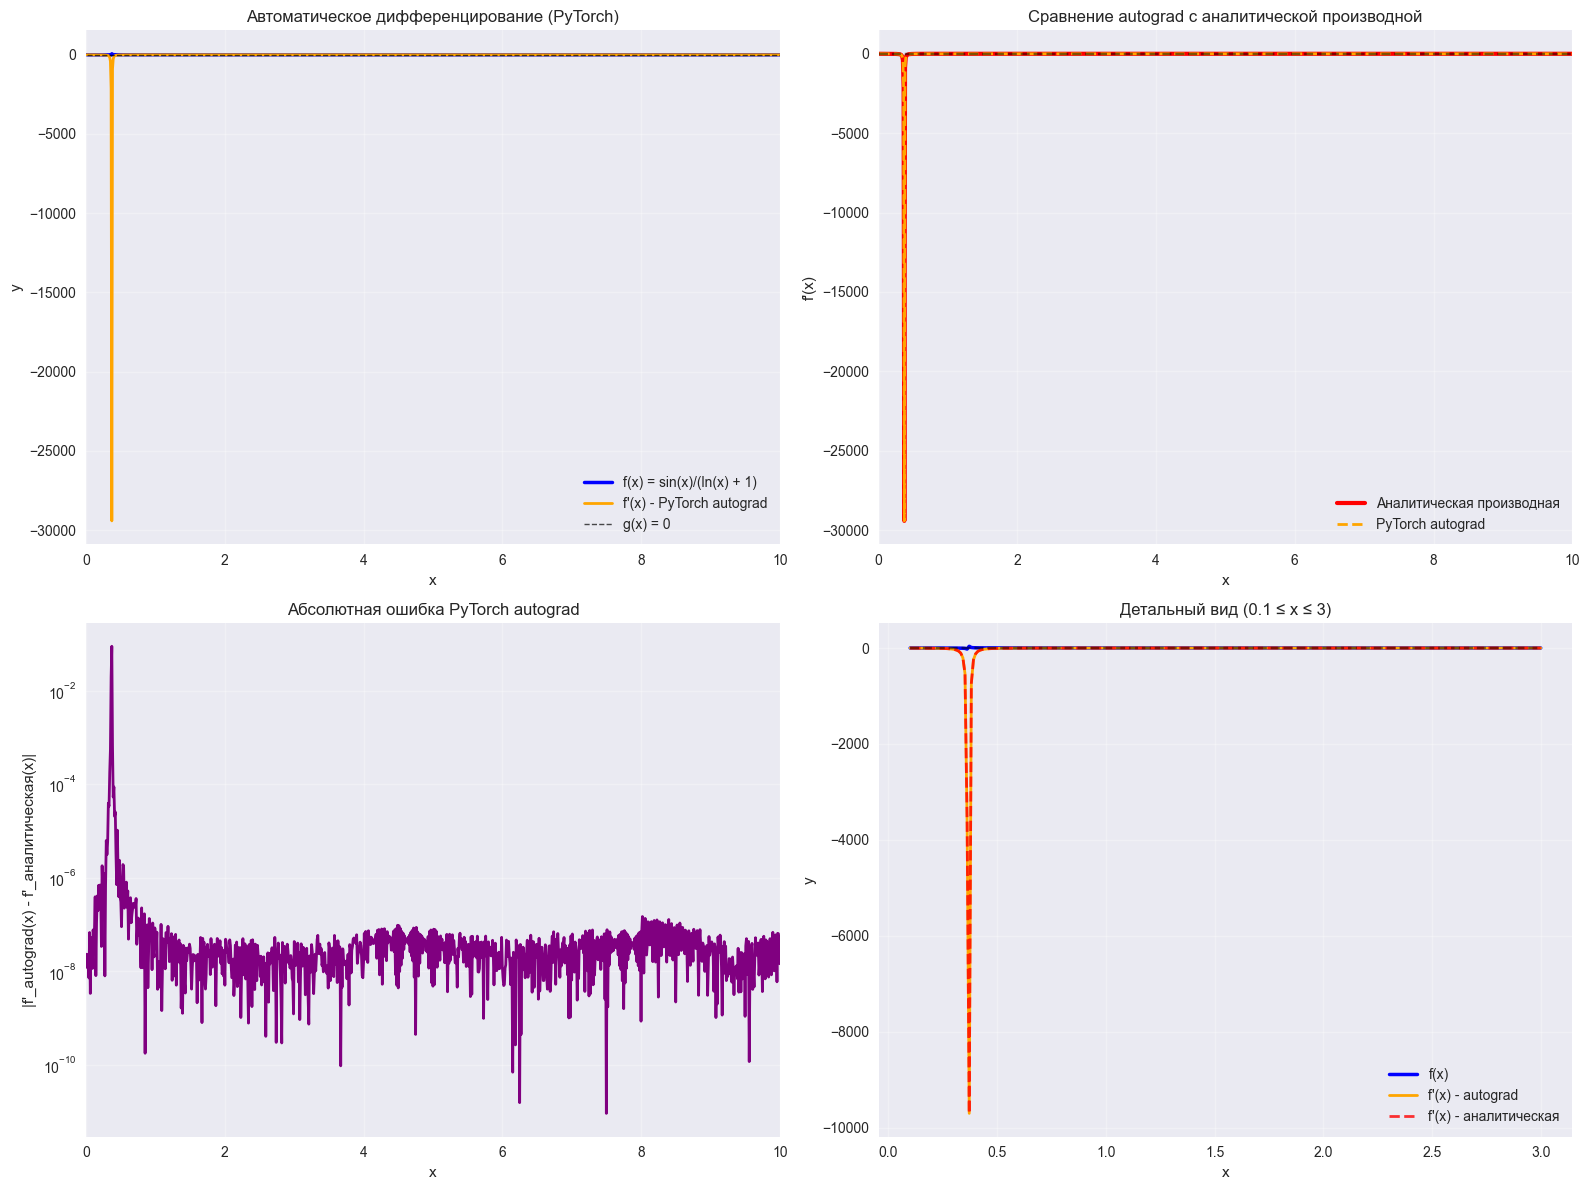


Точность PyTorch autograd:
Максимальная абсолютная ошибка: 8.86e-02
Средняя абсолютная ошибка: 1.10e-04

Сравнение в контрольных точках:
x      Аналитическая   PyTorch         Ошибка         
------------------------------------------------------------
0.5    -7.32340973     -7.32341003     3.07e-07       
1.0    -0.30116868     -0.30116862     5.84e-08       
2.0    -0.40437695     -0.40437695     5.07e-09       
5.0    0.13687193      0.13687193      4.83e-09       
8.0    -0.06029010     -0.06029010     8.63e-10       

PyTorch autograd показывает высокую точность, сравнимую с машинной точностью!


In [6]:
# Задача 5: Автоматическое дифференцирование с PyTorch

def f_torch(x):
    """Функция f(x) = sin(x)/(ln(x) + 1) для PyTorch"""
    return torch.sin(x) / (torch.log(x) + 1)

def compute_derivative_torch(x_vals):
    """Вычисление производной через автоматическое дифференцирование"""
    derivatives = []
    
    for x_val in x_vals:
        # Создаем тензор с включенным градиентом
        x_tensor = torch.tensor(float(x_val), requires_grad=True)
        
        # Вычисляем функцию
        y = f_torch(x_tensor)
        
        # Вычисляем градиент
        y.backward()
        
        # Сохраняем значение градиента
        derivatives.append(x_tensor.grad.item())
    
    return derivatives

# Построение графиков на полуинтервале (0, 10]
x_vals = np.linspace(0.01, 10, 1000)

# Вычисление значений функции (используем numpy версию для построения)
y_vals = f(x_vals)

# Вычисление производной через PyTorch autograd
print("Вычисление производной через PyTorch autograd...")
y_prime_torch = compute_derivative_torch(x_vals)

# Для сравнения - аналитическая производная
y_prime_analytical_vals = f_prime_analytical(x_vals)

zero_vals = np.zeros_like(x_vals)

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Функция и производная через autograd
axes[0, 0].plot(x_vals, y_vals, 'b-', label='f(x) = sin(x)/(ln(x) + 1)', linewidth=2.5)
axes[0, 0].plot(x_vals, y_prime_torch, 'orange', label="f'(x) - PyTorch autograd", linewidth=2)
axes[0, 0].plot(x_vals, zero_vals, 'k--', label='g(x) = 0', linewidth=1, alpha=0.7)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_title('Автоматическое дифференцирование (PyTorch)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_xlim(0, 10)

# График 2: Сравнение autograd с аналитической производной
axes[0, 1].plot(x_vals, y_prime_analytical_vals, 'r-', label='Аналитическая производная', linewidth=3)
axes[0, 1].plot(x_vals, y_prime_torch, 'orange', linestyle='--', 
               label='PyTorch autograd', linewidth=2)
axes[0, 1].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_title('Сравнение autograd с аналитической производной')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel("f'(x)")
axes[0, 1].set_xlim(0, 10)

# График 3: Ошибка autograd
error_torch = np.abs(np.array(y_prime_torch) - y_prime_analytical_vals)
axes[1, 0].semilogy(x_vals, error_torch, 'purple', linewidth=2)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_title('Абсолютная ошибка PyTorch autograd')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('|f\'_autograd(x) - f\'_аналитическая(x)|')
axes[1, 0].set_xlim(0, 10)

# График 4: Детальный вид для малых x
x_detail = np.linspace(0.1, 3, 300)
y_detail = f(x_detail)
y_prime_torch_detail = compute_derivative_torch(x_detail)
y_prime_analytical_detail = f_prime_analytical(x_detail)

axes[1, 1].plot(x_detail, y_detail, 'b-', label='f(x)', linewidth=2.5)
axes[1, 1].plot(x_detail, y_prime_torch_detail, 'orange', 
               label="f'(x) - autograd", linewidth=2)
axes[1, 1].plot(x_detail, y_prime_analytical_detail, 'r--', 
               label="f'(x) - аналитическая", linewidth=2, alpha=0.8)
axes[1, 1].plot(x_detail, np.zeros_like(x_detail), 'k--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_title('Детальный вид (0.1 ≤ x ≤ 3)')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')

plt.tight_layout()
plt.show()

# Анализ точности PyTorch autograd
max_error_torch = np.max(error_torch)
mean_error_torch = np.mean(error_torch)
print(f"\nТочность PyTorch autograd:")
print(f"Максимальная абсолютная ошибка: {max_error_torch:.2e}")
print(f"Средняя абсолютная ошибка: {mean_error_torch:.2e}")

# Проверка в контрольных точках
test_points = [0.5, 1.0, 2.0, 5.0, 8.0]
print(f"\nСравнение в контрольных точках:")
print(f"{'x':<6} {'Аналитическая':<15} {'PyTorch':<15} {'Ошибка':<15}")
print("-" * 60)
for x_test in test_points:
    analytical = f_prime_analytical(x_test)
    
    # PyTorch autograd для одной точки
    x_tensor = torch.tensor(x_test, requires_grad=True)
    y_tensor = f_torch(x_tensor)
    y_tensor.backward()
    torch_val = x_tensor.grad.item()
    
    error = abs(analytical - torch_val)
    print(f"{x_test:<6.1f} {analytical:<15.8f} {torch_val:<15.8f} {error:<15.2e}")

print("\nPyTorch autograd показывает высокую точность, сравнимую с машинной точностью!")

<p class="task" id="6"></p>

6\. Дана функция $f(x)$. Найдите производную данной функции $f'(x)$ на отрезке [0, 10] при помощи формулы производной сложной функции. На этом же отрезке найдите, используя возможности по автоматическому дифференцированию пакета `torch`. Сравните результаты.

$$f(x) = sin(cos(x))$$

Символьная функция:
f(x) = sin(cos(x))

Символьная производная (правило цепочки):
f'(x) = -sin(x)*cos(cos(x))

Упрощенная производная:
f'(x) = -sin(x)*cos(cos(x))

Вычисление производной через PyTorch autograd...


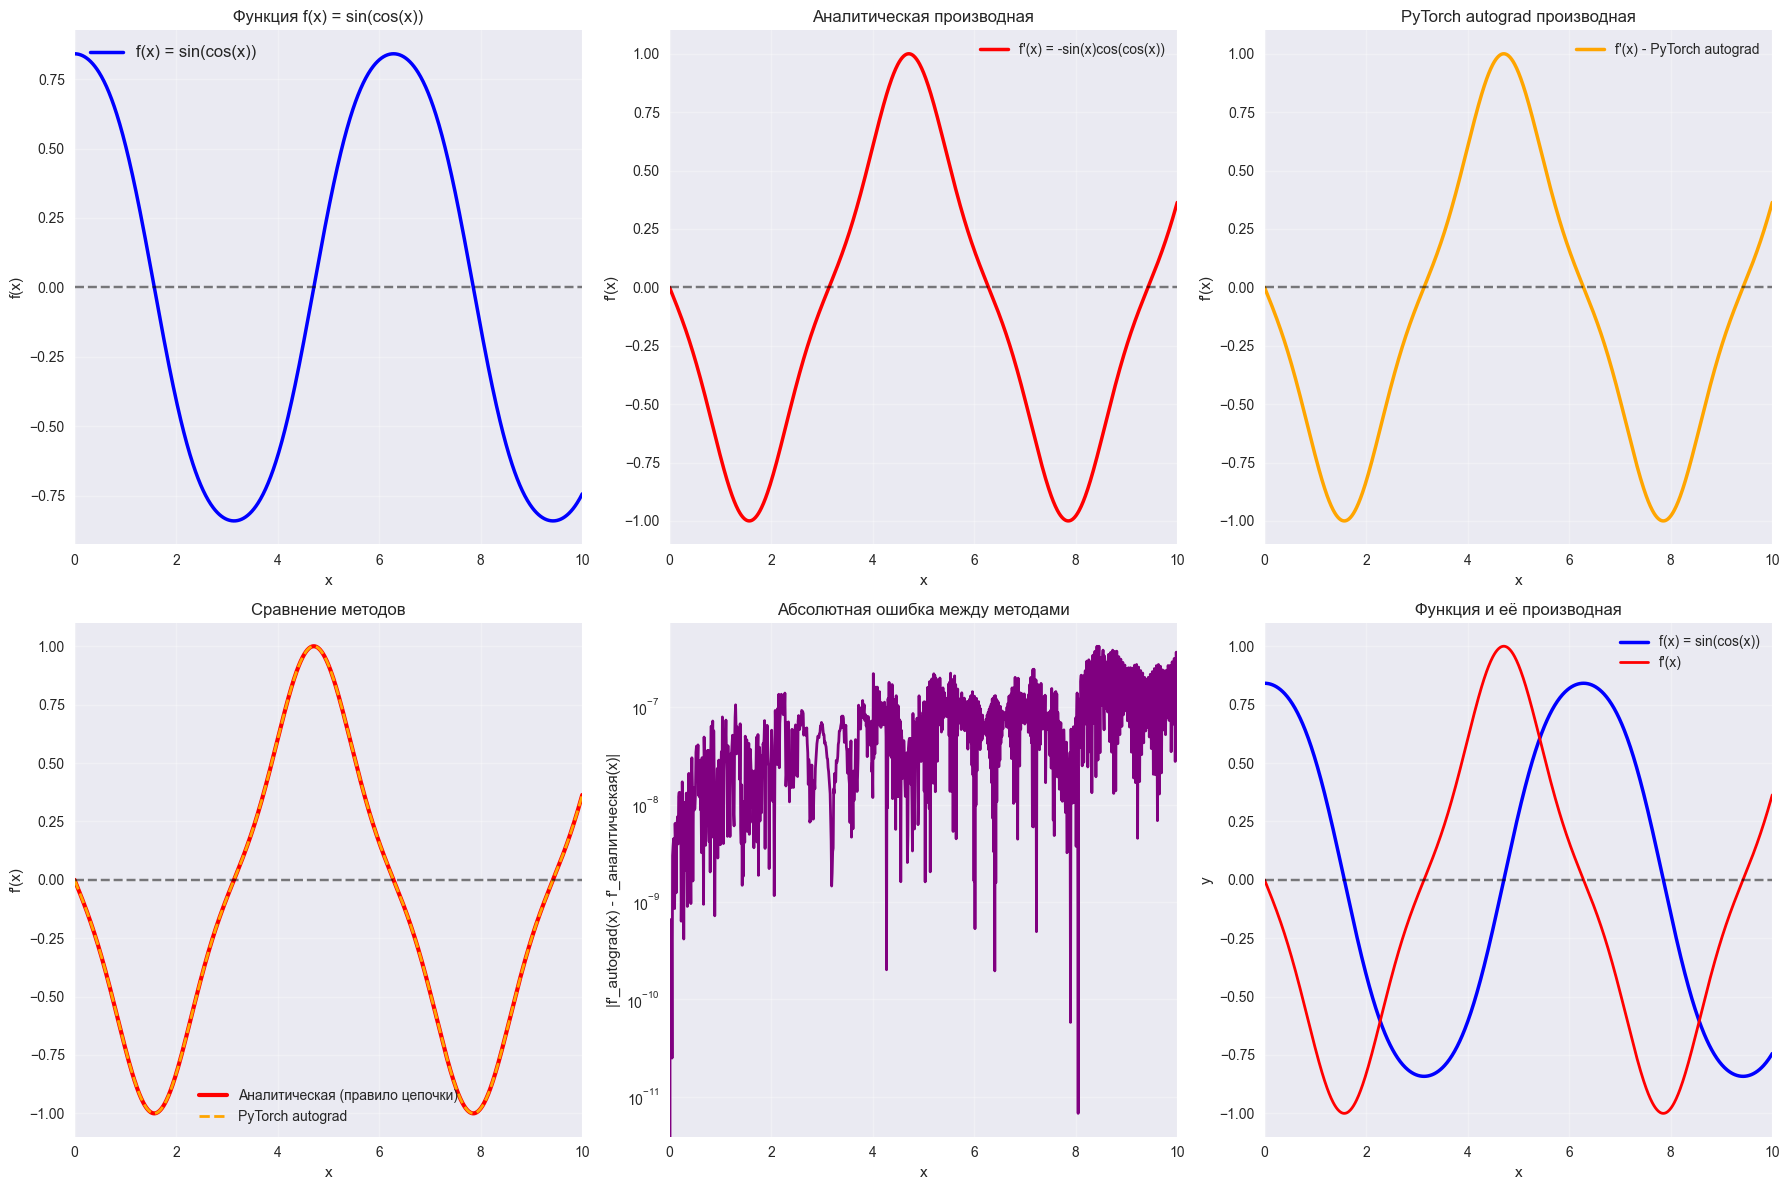


Сравнение результатов:
Максимальная абсолютная ошибка между методами: 4.24e-07
Средняя абсолютная ошибка между методами: 7.63e-08

Проверка в контрольных точках:
x          Аналитическая   PyTorch         Ошибка         
-----------------------------------------------------------------
0.0000     -0.00000000     -0.00000000     0.00e+00       
0.7854     -0.53757411     -0.53757411     2.46e-09       
1.5708     -1.00000000     -1.00000000     0.00e+00       
3.1416     -0.00000000     0.00000005      4.72e-08       
6.2832     0.00000000      -0.00000009     9.45e-08       
9.4248     -0.00000000     0.00000001      1.29e-08       

Вывод: PyTorch autograd автоматически применяет правило цепочки
и дает результаты, идентичные аналитическому дифференцированию!

Правило цепочки для f(x) = sin(cos(x)):
f'(x) = d/dx[sin(cos(x))] = cos(cos(x)) * d/dx[cos(x)] = cos(cos(x)) * (-sin(x)) = -sin(x) * cos(cos(x))


In [8]:
# Задача 6: Дифференцирование сложной функции f(x) = sin(cos(x))

# Аналитическое дифференцирование по правилу цепочки
# f(x) = sin(cos(x))
# f'(x) = cos(cos(x)) * (-sin(x)) = -sin(x) * cos(cos(x))

def f_composite(x):
    """Функция f(x) = sin(cos(x))"""
    return np.sin(np.cos(x))

def f_composite_derivative_analytical(x):
    """Аналитическая производная f'(x) = -sin(x) * cos(cos(x))"""
    return -np.sin(x) * np.cos(np.cos(x))

# PyTorch версия функции
def f_composite_torch(x):
    """Функция f(x) = sin(cos(x)) для PyTorch"""
    return torch.sin(torch.cos(x))

def compute_derivative_composite_torch(x_vals):
    """Вычисление производной сложной функции через PyTorch autograd"""
    derivatives = []
    
    for x_val in x_vals:
        x_tensor = torch.tensor(float(x_val), dtype=torch.float32, requires_grad=True)
        y = f_composite_torch(x_tensor)
        y.backward()
        derivatives.append(x_tensor.grad.item())
    
    return derivatives

# Символьное дифференцирование для проверки
x_sym = sp.Symbol('x')
f_composite_symbolic = sp.sin(sp.cos(x_sym))
f_composite_derivative_symbolic = sp.diff(f_composite_symbolic, x_sym)

print("Символьная функция:")
print(f"f(x) = {f_composite_symbolic}")
print("\nСимвольная производная (правило цепочки):")
print(f"f'(x) = {f_composite_derivative_symbolic}")
print("\nУпрощенная производная:")
f_composite_simplified = sp.simplify(f_composite_derivative_symbolic)
print(f"f'(x) = {f_composite_simplified}")

# Построение графиков на отрезке [0, 10]
x_vals = np.linspace(0, 10, 1000)

# Вычисление значений функции
y_vals = f_composite(x_vals)

# Вычисление производной аналитически
y_prime_analytical = f_composite_derivative_analytical(x_vals)

# Вычисление производной через PyTorch autograd
print("\nВычисление производной через PyTorch autograd...")
y_prime_torch = compute_derivative_composite_torch(x_vals)

zero_vals = np.zeros_like(x_vals)

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График 1: Функция sin(cos(x))
axes[0, 0].plot(x_vals, y_vals, 'b-', label='f(x) = sin(cos(x))', linewidth=2.5)
axes[0, 0].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=12)
axes[0, 0].set_title('Функция f(x) = sin(cos(x))', fontsize=12)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('f(x)')
axes[0, 0].set_xlim(0, 10)

# График 2: Аналитическая производная
axes[0, 1].plot(x_vals, y_prime_analytical, 'r-', label="f'(x) = -sin(x)cos(cos(x))", linewidth=2.5)
axes[0, 1].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=10)
axes[0, 1].set_title('Аналитическая производная', fontsize=12)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel("f'(x)")
axes[0, 1].set_xlim(0, 10)

# График 3: PyTorch autograd производная
axes[0, 2].plot(x_vals, y_prime_torch, 'orange', label="f'(x) - PyTorch autograd", linewidth=2.5)
axes[0, 2].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend(fontsize=10)
axes[0, 2].set_title('PyTorch autograd производная', fontsize=12)
axes[0, 2].set_xlabel('x')
axes[0, 2].set_ylabel("f'(x)")
axes[0, 2].set_xlim(0, 10)

# График 4: Сравнение методов
axes[1, 0].plot(x_vals, y_prime_analytical, 'r-', label='Аналитическая (правило цепочки)', linewidth=3)
axes[1, 0].plot(x_vals, y_prime_torch, 'orange', linestyle='--', 
               label='PyTorch autograd', linewidth=2)
axes[1, 0].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)
axes[1, 0].set_title('Сравнение методов', fontsize=12)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel("f'(x)")
axes[1, 0].set_xlim(0, 10)

# График 5: Ошибка между методами
error_comparison = np.abs(np.array(y_prime_torch) - y_prime_analytical)
axes[1, 1].semilogy(x_vals, error_comparison, 'purple', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_title('Абсолютная ошибка между методами', fontsize=12)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('|f\'_autograd(x) - f\'_аналитическая(x)|')
axes[1, 1].set_xlim(0, 10)

# График 6: Функция и производная вместе
axes[1, 2].plot(x_vals, y_vals, 'b-', label='f(x) = sin(cos(x))', linewidth=2.5)
axes[1, 2].plot(x_vals, y_prime_analytical, 'r-', label="f'(x)", linewidth=2)
axes[1, 2].plot(x_vals, zero_vals, 'k--', alpha=0.5)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(fontsize=10)
axes[1, 2].set_title('Функция и её производная', fontsize=12)
axes[1, 2].set_xlabel('x')
axes[1, 2].set_ylabel('y')
axes[1, 2].set_xlim(0, 10)

plt.tight_layout()
plt.show()

# Детальный анализ точности
max_error_comparison = np.max(error_comparison)
mean_error_comparison = np.mean(error_comparison)

print(f"\nСравнение результатов:")
print(f"Максимальная абсолютная ошибка между методами: {max_error_comparison:.2e}")
print(f"Средняя абсолютная ошибка между методами: {mean_error_comparison:.2e}")

# Проверка правила цепочки в контрольных точках
test_points = [0, np.pi/4, np.pi/2, np.pi, 2*np.pi, 3*np.pi]
print(f"\nПроверка в контрольных точках:")
print(f"{'x':<10} {'Аналитическая':<15} {'PyTorch':<15} {'Ошибка':<15}")
print("-" * 65)

for x_test in test_points:
    analytical = f_composite_derivative_analytical(x_test)
    
    # PyTorch autograd
    x_tensor = torch.tensor(x_test, dtype=torch.float32, requires_grad=True)
    y_tensor = f_composite_torch(x_tensor)
    y_tensor.backward()
    torch_val = x_tensor.grad.item()
    
    error = abs(analytical - torch_val)
    print(f"{x_test:<10.4f} {analytical:<15.8f} {torch_val:<15.8f} {error:<15.2e}")

print("\nВывод: PyTorch autograd автоматически применяет правило цепочки")
print("и дает результаты, идентичные аналитическому дифференцированию!")
print("\nПравило цепочки для f(x) = sin(cos(x)):")
print("f'(x) = d/dx[sin(cos(x))] = cos(cos(x)) * d/dx[cos(x)] = cos(cos(x)) * (-sin(x)) = -sin(x) * cos(cos(x))")